In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
#read the words
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [ ]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [ ]:
# build the dataset
block_size = 8 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%


torch.Size([182580, 8]) torch.Size([182580])
torch.Size([22767, 8]) torch.Size([22767])
torch.Size([22799, 8]) torch.Size([22799])


In [ ]:
n_embd = 10
n_hidden = 200
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,10),generator=g)

W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5) #* 0.2
#b1 = torch.randn(200,generator=g) * 0.1
W2 = torch.randn((200,27),generator=g) * 0.1
b2 = torch.randn(27,generator=g) * 0

# BatchNorm parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C,W1,W2,b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

22097


In [ ]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [ ]:
lri = []
lossi = []


In [ ]:
e = torch.randn(4,8,10)
explicit = torch.cat([e[:, ::2, :],e[:, 1::2, :]],dim=2)
explicit.shape

torch.Size([4, 4, 20])

In [ ]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
  # BatchNorm layer
  # -------------------------------------------------------------
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
  # -------------------------------------------------------------
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 2.2652
  10000/ 200000: 2.0540
  20000/ 200000: 2.3832
  30000/ 200000: 2.1190
  40000/ 200000: 2.1534
  50000/ 200000: 2.1182
  60000/ 200000: 2.2892
  70000/ 200000: 2.3992
  80000/ 200000: 2.2235
  90000/ 200000: 1.9602
 100000/ 200000: 2.1697
 110000/ 200000: 2.3629
 120000/ 200000: 2.1485
 130000/ 200000: 1.7836
 140000/ 200000: 2.0366
 150000/ 200000: 2.0422
 160000/ 200000: 1.9967
 170000/ 200000: 1.6695
 180000/ 200000: 2.0550
 190000/ 200000: 2.1459


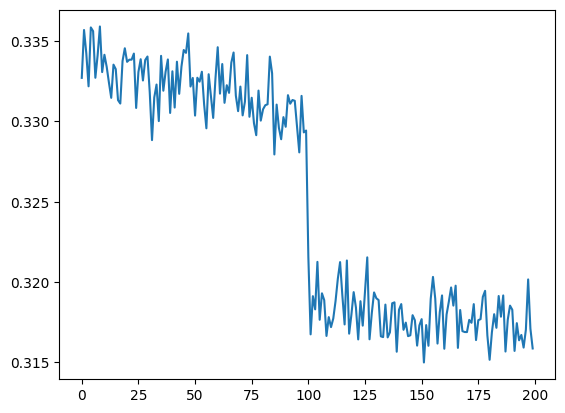

In [ ]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [ ]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 # + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)


In [ ]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 # + b1
  #hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0702993869781494
val 2.1078312397003174


In [ ]:
g = torch.Generator().manual_seed(2147483647)

for _ in range(10): # generate 10 names
  with torch.no_grad(): # disable gradient tracking for inference
    out =[]
    context = [0]*block_size
    while(True):
      emb = C[torch.tensor([context])] # (1, block_size, n_embd)
      embcat = emb.view(1, -1) # (1, block_size * n_embd)
      hpreact = embcat @ W1 # Linear layer
      hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias # BatchNorm
      h = torch.tanh(hpreact) # Non-linearity
      logits = h @ W2 + b2 # Output layer
      probs = F.softmax(logits,dim=1)
      ix = torch.multinomial(probs,num_samples=1,generator = g).item()
      context = context[1:]+[ix]
      out.append(ix)
      if ix == 0:
        break
    print(''.join(itos[i] for i in out ))

dex.
marial.
makilah.
tydiell.
imitta.
nella.
kama.
darreliyah.
jaxson.
mari.


# **Pytorchifying**

In [ ]:
class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    params = [self.weight]
    if self.bias is not None:
      params.append(self.bias)
    return params

class Batchnormld:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    #parameters trained with backprop
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    #parameters used at inference time
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    #calculate the forward pass
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0,1)
      xmean = x.mean(0, keepdim=True) #batch mean
      xvar = x.var(0, keepdim=True , unbiased = True) #batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) #normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    #update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self,x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

class Embeddings:
  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))
  def __call__(self,IX):
    self.out = self.weight[IX]
    return self.out
  def parameters(self):
    return [self.weight]

class FlattenConsecutive:

  def __init__(self, n):
    self.n = n

  def __call__(self, x):
    B,T,C = x.shape
    x= x.view(B,T//self.n,C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)
    self.out = x
    return self.out

  def parameters(self):
    return[]

class Sequential:

  def __init__(self,layers):
    self.layers = layers

  def __call__(self,x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

n_embd = 24 #dimension of the character embeddding vector
n_hidden = 200 #num of neurons in hidden layer of MLP (adjusted for ~170k parameters)
g = torch.Generator().manual_seed(2147483647)

layers = [
    Embeddings(vocab_size, n_embd),
    FlattenConsecutive(2),
    Linear(n_embd * 2, n_hidden, bias=False), Batchnormld(n_hidden), Tanh(),
    FlattenConsecutive(2),
    Linear(n_hidden * 2, n_hidden, bias=False), Batchnormld(n_hidden), Tanh(),
    FlattenConsecutive(2),
    Linear(n_hidden * 2, n_hidden, bias=False), Batchnormld(n_hidden),
    Linear(n_hidden, vocab_size, bias=True)
    ]

with torch.no_grad():
  # last layer: make less confident
  layers[-1].weight *= 0.1 # This now targets the final Linear layer's weight
  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 1.0 #5/3

# Instantiate the Sequential model
model = Sequential(layers)

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

176875


In [ ]:
max_steps = 100000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  model(Xb) # Perform the forward pass, which populates model.out
  logits = model.out # Get the actual output tensor
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  for layer in layers:
    if hasattr(layer, 'out') and layer.out.requires_grad: # Check if 'out' exists and requires grad before retaining
      layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every 10000 steps
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  #if i >= 1000:
    #break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 100000: 3.2917
  10000/ 100000: 1.6084
  20000/ 100000: 1.8089
  30000/ 100000: 2.1694
  40000/ 100000: 1.9438
  50000/ 100000: 1.8073
  60000/ 100000: 1.7061
  70000/ 100000: 1.8326
  80000/ 100000: 2.2466
  90000/ 100000: 1.8846


layer 4 (      Tanh): mean +0.03, std 0.73, saturated: 20.53%
layer 7 (      Tanh): mean +0.01, std 0.78, saturated: 23.19%
layer 10 (      Tanh): mean +0.01, std 0.81, saturated: 28.78%
layer 13 (      Tanh): mean -0.00, std 0.82, saturated: 31.12%


/tmp/ipykernel_1884/1397477801.py:7: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))


Text(0.5, 1.0, 'activation distribution')

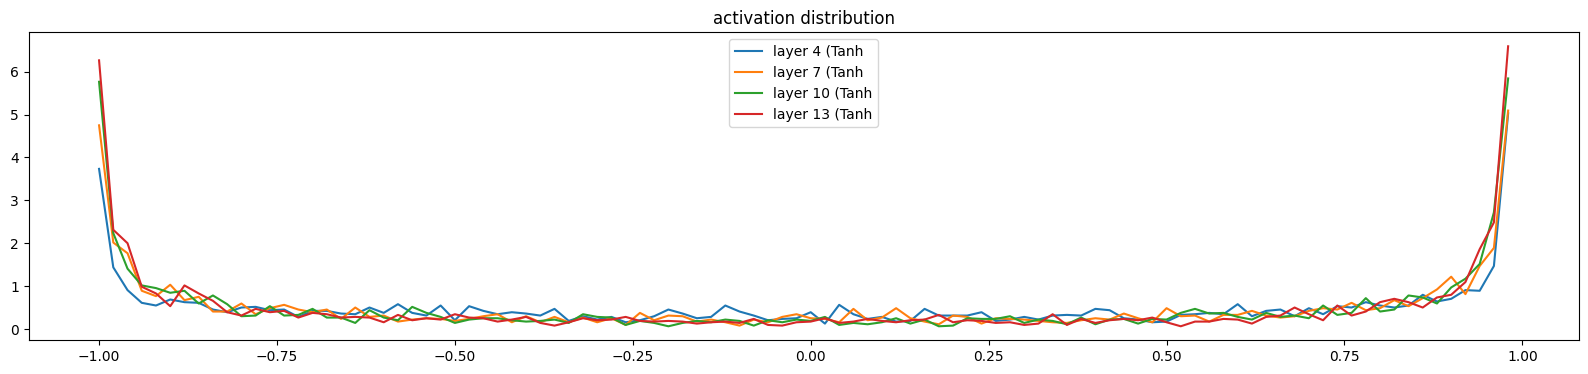

In [ ]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 4 (      Tanh): mean -0.000000, std 4.115958e-03
layer 7 (      Tanh): mean +0.000000, std 3.781667e-03
layer 10 (      Tanh): mean +0.000000, std 3.606711e-03
layer 13 (      Tanh): mean -0.000000, std 3.522725e-03


Text(0.5, 1.0, 'gradient distribution')

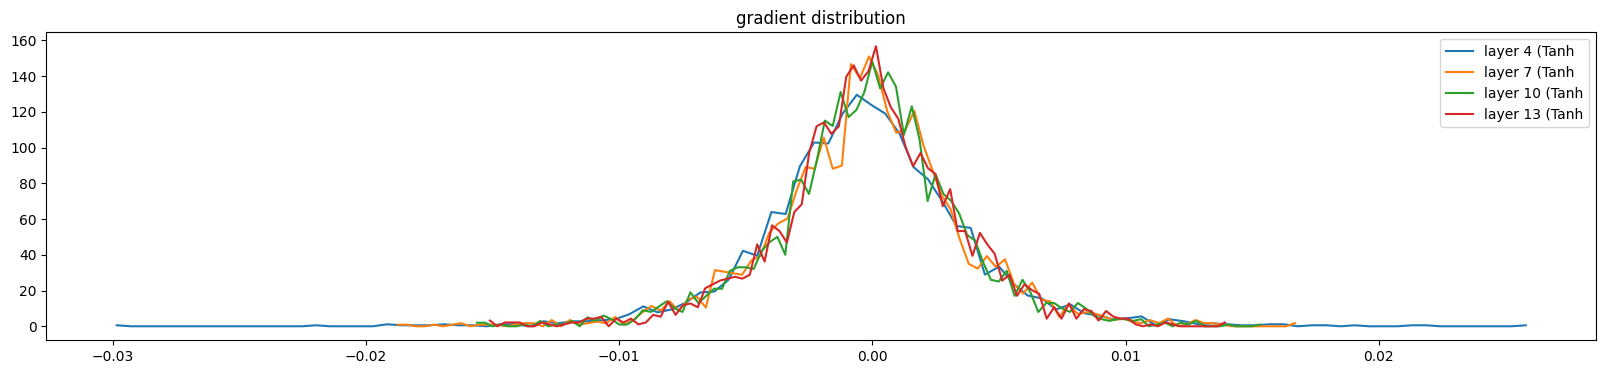

In [ ]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean +0.000000 | std 1.906509e-02 | grad:data ratio 1.539558e-02
weight  (30, 100) | mean +0.000363 | std 9.169639e-03 | grad:data ratio 1.994462e-02
weight (100, 100) | mean +0.000044 | std 5.570354e-03 | grad:data ratio 1.975269e-02
weight (100, 100) | mean +0.000024 | std 5.475135e-03 | grad:data ratio 1.992750e-02
weight (100, 100) | mean +0.000015 | std 5.420694e-03 | grad:data ratio 2.103557e-02
weight  (100, 27) | mean +0.000037 | std 7.440086e-03 | grad:data ratio 1.848415e-02


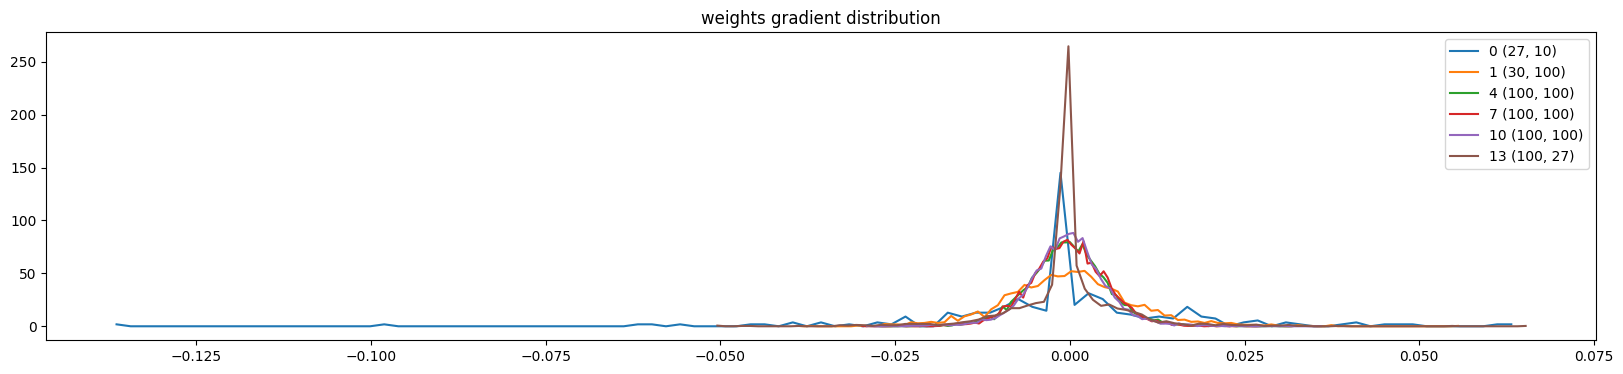

In [ ]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

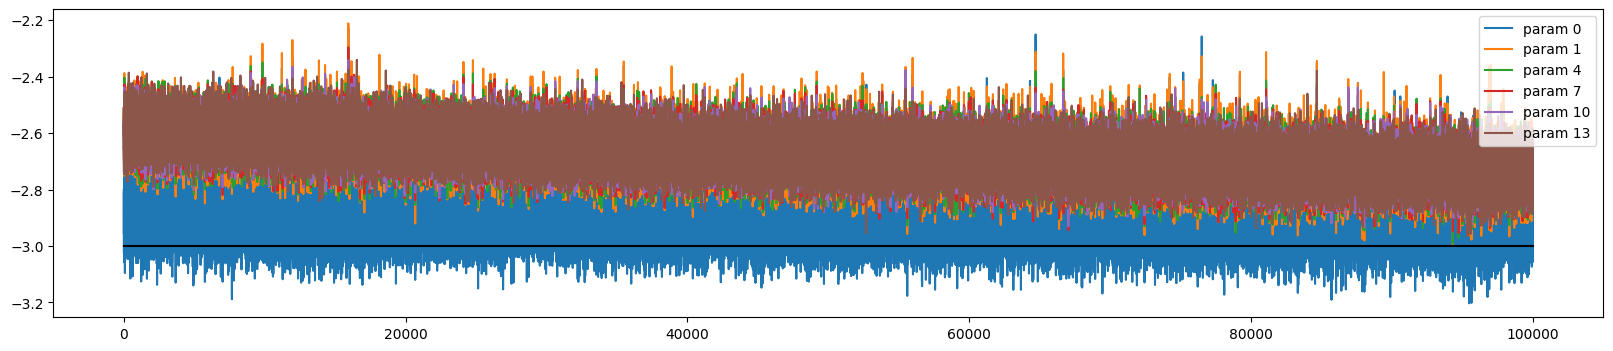

In [ ]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);


In [ ]:
for layer in model.layers :
  layer.training = False

In [ ]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]

  model(x) # Perform the forward pass, which populates model.out
  logits = model.out # Get the actual output tensor
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

# put layers into eval mode
for layer in layers:
  layer.training = False
split_loss('train')
split_loss('val')

train 1.92808198928833
val 2.04118275642395


In [ ]:
#train 2.391305685043335
#val 2.3916704654693604

In [ ]:
g = torch.Generator().manual_seed(2147483647 + 10)

# Set all Batchnormld layers to evaluation mode
# This assumes the running_mean and running_var have been populated by training.
for layer in layers:
  if isinstance(layer, Batchnormld):
    layer.training = False

for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      model(torch.tensor([context])) # Perform the forward pass, which populates model.out
      logits = model.out
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break

    print(''.join(itos[i] for i in out)) # decode and print the generated word

carmah.
amilli.
khirmoni.
tatyanna.
saneja.
hutnfard.
rhett.
quianna.
kingzimii.
desley.
philmo.
sinderson.
sulivaan.
addison.
trogiearyn.
kaine.
pinsleigh.
emili.
gilesha.
franasa.


In [ ]:
# Fuses the parameters of a trained Batch Normalization layer
#into the preceding Linear layer's weights and biases to optimize inference speed.


import torch

lin_layer = layers[0]
bn_layer = layers[1]

W = lin_layer.weight
b = lin_layer.bias if lin_layer.bias is not None else torch.zeros_like(bn_layer.running_mean)
gamma = bn_layer.gamma
beta = bn_layer.beta
mean = bn_layer.running_mean
var = bn_layer.running_var
eps = bn_layer.eps

std_adj = torch.sqrt(var + eps)

W_fold = W * (gamma / std_adj)
b_fold = (gamma / std_adj) * (b - mean) + beta

fan_in = lin_layer.weight.shape[0]
fan_out = lin_layer.weight.shape[1]
folded_layer = Linear(fan_in, fan_out, bias=True)

folded_layer.weight = W_fold
folded_layer.bias = b_fold

x_test = torch.randn(32, fan_in)

bn_layer.training = False
original_out = bn_layer(lin_layer(x_test))
folded_out = folded_layer(x_test)

print(torch.allclose(original_out, folded_out, atol=1e-5))

True
